# Point statistics

To assess whether transcript assignments are spatially consistent with a segmentation, we provide a set of metrics in the `ps` (point statistics) module. The idea of this module is to provide an intuition whether transcripts are distributed unequally, meaning they are more likely to have resulted from a spillover from neighbouring cells. This can happen due to imperfect boundaries, dense packing, partial overlaps, and other sources of “spillover” between adjacent cells.

The `ps` module summarizes transcript localization relative to cell (and optionally nucleus) geometry, providing intuitive signals for potential contamination or biased spatial distributions. Metrics can be returned as a table and, if desired, stored in place in the `SpatialData` object.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load data into SegTraQ and run label transfer

In [30]:
import copy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import spatialdata as sd
import spatialdata_plot  # noqa
import segtraq
import anndata as ad
import numpy as np
from pathlib import Path

In [3]:
data_path = Path("/g/huber/projects/CODEX/segtraq/data/20260113_Janesick_Replicate1/xenium")

We load [previously built](./io.ipynb) `SpatialData` objects from 10x Genomics Xenium data segmented with Xenium's multimodal cell segmentation (`sdata_xenium`), with Proseg v2.0.5 (`sdata_proseg2`) and Proseg v3.1.0 (`sdata_proseg3`).

In [4]:
sdata_xenium = sd.read_zarr(data_path / "sdata_xenium_crop.zarr")
sdata_proseg2 = sd.read_zarr(data_path / "proseg_output_v2/sdata_proseg_crop.zarr")

We initialize `SegTraQ` objects. 

In [5]:
st_xenium = segtraq.SegTraQ(
    sdata_xenium,
    tables_centroid_x_key=None,
    tables_centroid_y_key=None,
    points_background_id=-1,  # "UNASSIGNED" for Xenium prime
)

st_proseg2 = segtraq.SegTraQ(
    sdata_proseg2,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_key="volume",
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:132: RuntimeWarning: No centroids specified for tables. Centroids will be automatically computed from shapes.
  validate_spatialdata(


For easier access, we store the `SpatialData` object into a dictionary.

In [6]:
st_dict = {"xenium": st_xenium, "proseg2": st_proseg2}

Finally, we filter out transcripts bound by control probes and those with a qv < 20. 

In [7]:
control_probes = [
    "NegControlProbe_",
    "antisense_",
    "NegControlCodeword",
    "BLANK_",
    "Blank-",
    "NegPrb",
    "DeprecatedCodeword_",
    "Intergenic_Region_",
    "UnassignedCodeword_",
]

for _method, st in st_dict.items():
    st.filter_control_and_poor_quality_transcripts()

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:624: RuntimeWarning: Some of the filtered genes (313) also appear in the tables. These genes are: ['NCAM1', 'ADH1B', 'AIF1', 'LYPD3', 'PCOLCE']... If you wish to recompute the expression matrix after filtering, set recompute_expression=True.
  _filter_control_and_poor_quality_transcripts(


We can then transfer labels from a reference scRNA-seq dataset. 

In [8]:
adata_ref = ad.read_h5ad("../../data/BC_scRNAseq_Janesick.h5ad")

for _method, st in st_dict.items():
    st.run_label_transfer(
        adata_ref, ref_cell_type="celltype_major", inplace=True, ref_ensemble_key=None, query_ensemble_key=None
    )

/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:381: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ref_mean_df = counts_df.groupby("celltype").mean()
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:356: RuntimeWarning: Spatialdata table appears to contain raw counts. Counts will be log1p-transformed before running label transfer.Raw counts will be stored in `adata_q.layers["raw"]`.
  result = _run_label_transfer(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:424: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  adata_q.layers["raw"] = adata_q.X
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:381: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass 

## Centroid mean coordinate difference

To assess whether transcripts assigned to a cell are spatially balanced within its geometry, we compare the mean transcript coordinate (i.e. the transcript center of mass) to a reference centroid derived from the segmentation.

For each cell, we compute the Euclidean distance between the mean transcript position $\mu_{x,y}$ and a centroid $cc_{x,y}$, which can be defined either by the cell outline or by a matched nucleus. When nuclei are used, each cell is first paired with a nucleus based on geometric overlap. Optionally, the calculation can be restricted to transcripts that lie within the cell. Because absolute distances scale with cell size, the displacement is normalized by a cell-specific length scale $|C|$, enabling comparisons across different cell sizes (`distance_norm_<feature>`).

$$
d_{centroid-mean} = \frac{\sqrt{cc_{x,y}^2-\mu_{x,y}^2}}{\sqrt{|C|}}
$$

The metric can be computed for a single gene, a selected set of genes, or for all transcripts jointly. Larger values indicate a stronger spatial bias of transcripts toward one side of the cell (or nucleus), which may reflect polarized expression patterns, boundary leakage, or spillover from neighboring cells.

We first compute this metric on Proseg-segmented data, which allows transcript repositioning—meaning that transcripts assigned to a cell may lie outside its segmented boundary. We focus on transcripts of the gene ERBB2 and compare the average normalized centroid–mean distance (`distance_to_cell_centroid__norm_ERBB2`) when transcripts are restricted to lie within the cell boundary (`restrict_to_within_boundary=True`) versus when all assigned transcripts are used.

As expected, restricting the calculation to transcripts inside the cell leads to a lower mean distance to the centroid.

In [18]:
# restricting to boudnary
_distance_to_centroid = st_proseg2.ps.centroid_mean_coord_diff(genes="ERBB2", 
                               restrict_to_within_boundary=True)
st_proseg2.sdata["table"].obs["distance_to_cell_centroid_norm_ERBB2"].mean()

np.float64(0.11881126476473122)

In [19]:
# not restricting to boundary
_distance_to_centroid = st_proseg2.ps.centroid_mean_coord_diff(genes="ERBB2", 
                               restrict_to_within_boundary=False)
st_proseg2.sdata["table"].obs["distance_to_cell_centroid_norm_ERBB2"].mean()

np.float64(0.16671939617234155)

We can visualise these results in space for the gene ERBB2

WARNING  Found 1093 NaN values in color data. These observations will be colored with the 'na_color'.              
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


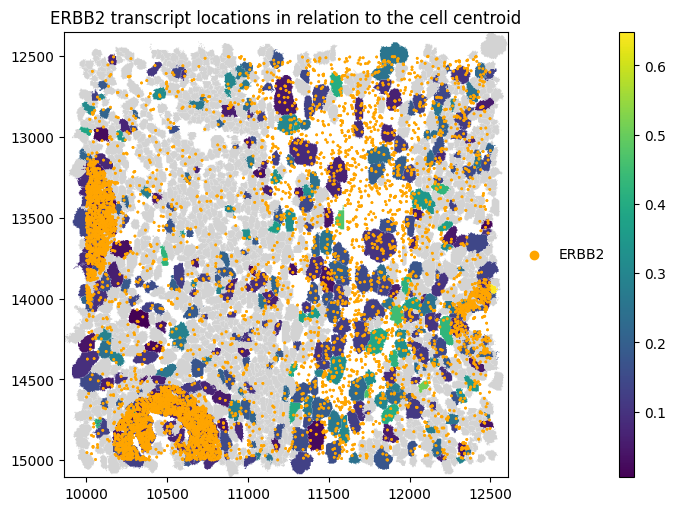

In [20]:
st_proseg2.sdata.pl.render_shapes(
    "cell_boundaries",
    color="distance_norm_ERBB2",
).pl.render_points(
    "transcripts",
    color="gene",
    groups=["ERBB2"],
    palette=["orange"],
).pl.show(
    title="ERBB2 transcript locations in relation to the cell centroid",
    coordinate_systems="global",
    figsize=(10, 5),
)

We can do the same for Xenium-segmented data.

In [21]:
_distance_to_centroid = st_xenium.ps.centroid_mean_coord_diff(genes="ERBB2", 
                               restrict_to_within_boundary=True)

WARNING  Found 562 NaN values in color data. These observations will be colored with the 'na_color'.               
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


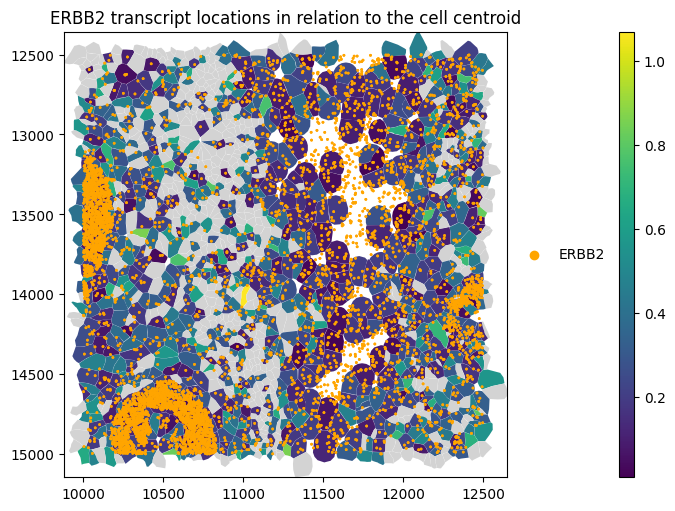

In [23]:
st_xenium.sdata.pl.render_shapes(
    "cell_boundaries",
    color="distance_to_cell_centroid_norm_ERBB2",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=["ERBB2"],
    palette=["orange"],
).pl.show(
    title="ERBB2 transcript locations in relation to the cell centroid",
    coordinate_systems="global",
    figsize=(10, 5),
)

When computing the distance across all transcripts (`genes=None`), the average `distance_all_genes` is close to zero, as the mean transcript position converges toward the cell centroid when many points are averaged.

We might also be interested in whether a gene's transcripts are further away from the cell than the nucleus centroid.

In [42]:
for _method, st in st_dict.items():
    st.ps.centroid_mean_coord_diff(centroid_region="nucleus", genes="ERBB2", restrict_to_within_boundary=True)

WARNING  Found 991 NaN values in color data. These observations will be colored with the 'na_color'.               
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
WARNING  Found 1093 NaN values in color data. These observations will be colored with the 'na_color'.              
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


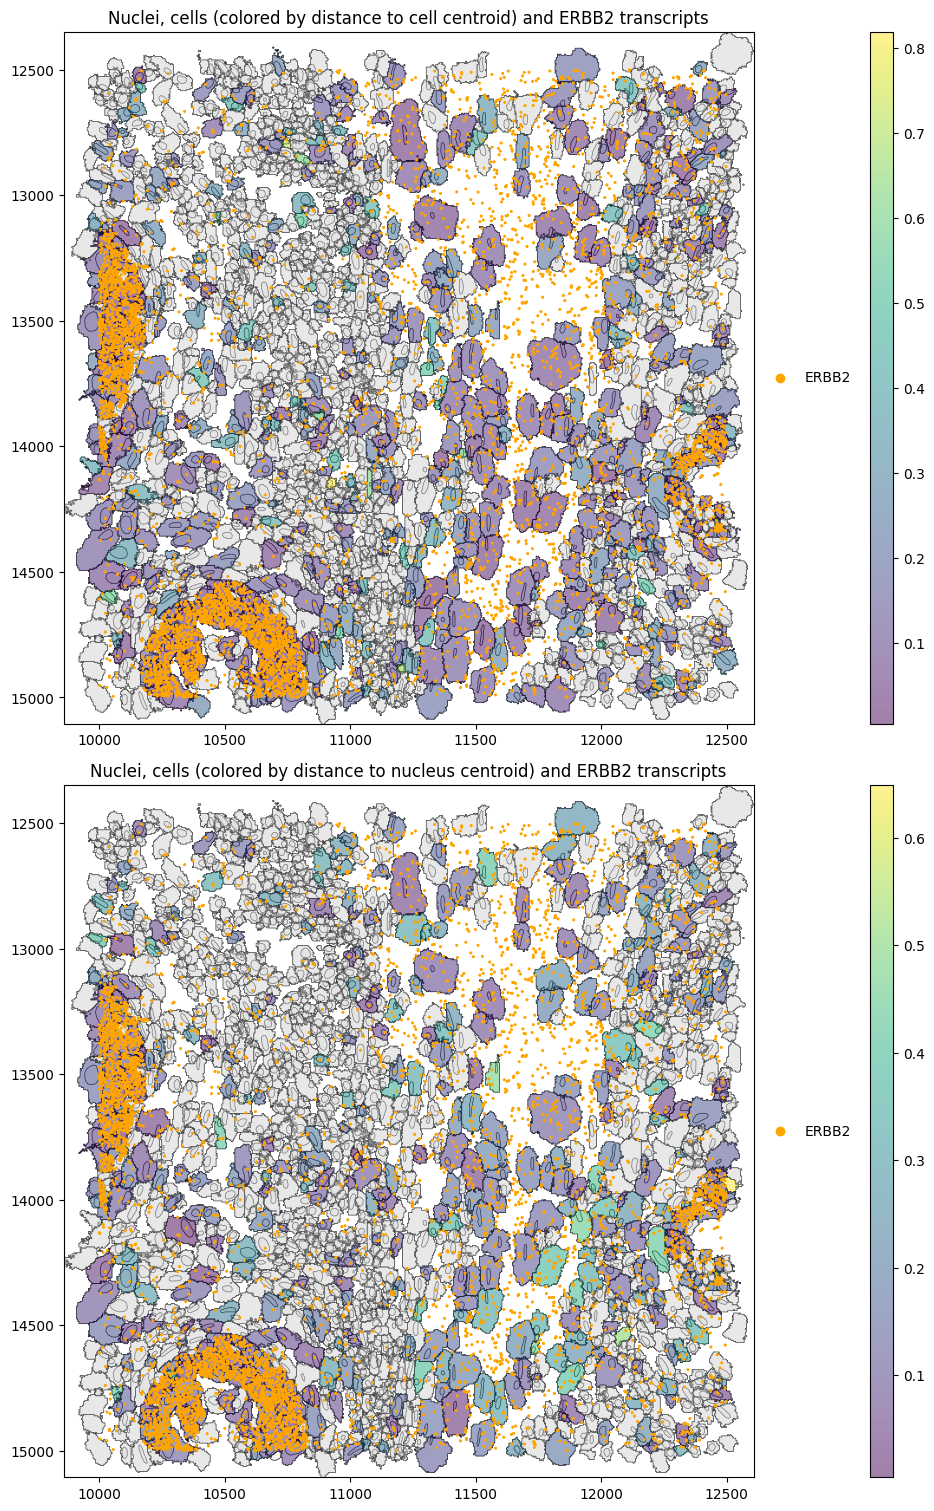

In [43]:
axes = plt.subplots(2, 1, figsize=(15, 15), constrained_layout=True)[1].flatten()

st_proseg2.sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="distance_to_cell_centroid_norm_ERBB2",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_points(
    "transcripts",
    color="gene",
    groups=["ERBB2"],
    palette=["orange"],
).pl.show(ax=axes[0], title="Nuclei, cells (colored by distance to cell centroid) and ERBB2 transcripts", colorbar=True)

st_proseg2.sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="distance_to_nucleus_centroid_norm_ERBB2",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_points(
    "transcripts",
    color="gene",
    groups=["ERBB2"],
    palette=["orange"],
).pl.show(ax=axes[1], title="Nuclei, cells (colored by distance to nucleus centroid) and ERBB2 transcripts", colorbar=True)

## Distance to membrane

Another way to look at the spatial distribution of transcripts is the distance of a gene's transcripts to the boundary (membrane). In some sense, this is complementary to the `centroid_mean_coord_diff` metric. However, in the case of very irregularly shaped cells, the distance to the membrane is a more direct measure of unequal transcript distribution and hence potential spillover.  

For each transcript, we compute its distance to the selected boundary, defined either by the cell outline or by a matched nucleus. Distances can be treated as signed (positive inside/on the boundary, negative outside), setting `signed=True`, and the computation can optionally be restricted to transcripts that lie within the selected boundary (`restrict_to_within_boundary=True`). 

The per-cell metric is defined as the mean distance to the cell/nuclear membrane $\mu(d(m,t))$ (as provided in the `spatialdata` object) divided by boundary-specific length-scale $\sqrt{|B|}$.
Again, this can be applied either to specific genes or all genes simultaneously.

$$
d_{membrane} = \frac{\mu(d(m,t))}{\sqrt{|B|}}
$$

Let's investigate the distance of MS4A1 (a B-cell marker) in B cells. Below it looks like MS4A1 is mostly expressed in the nucleus.

In [64]:
for _method, st in st_dict.items():
    st.ps.distance_to_membrane(genes = "MS4A1", 
                                   cell_type_query="B", 
                                   restrict_to_within_boundary=True)

WARNING  Found 1537 NaN values in color data. These observations will be colored with the 'na_color'.              
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


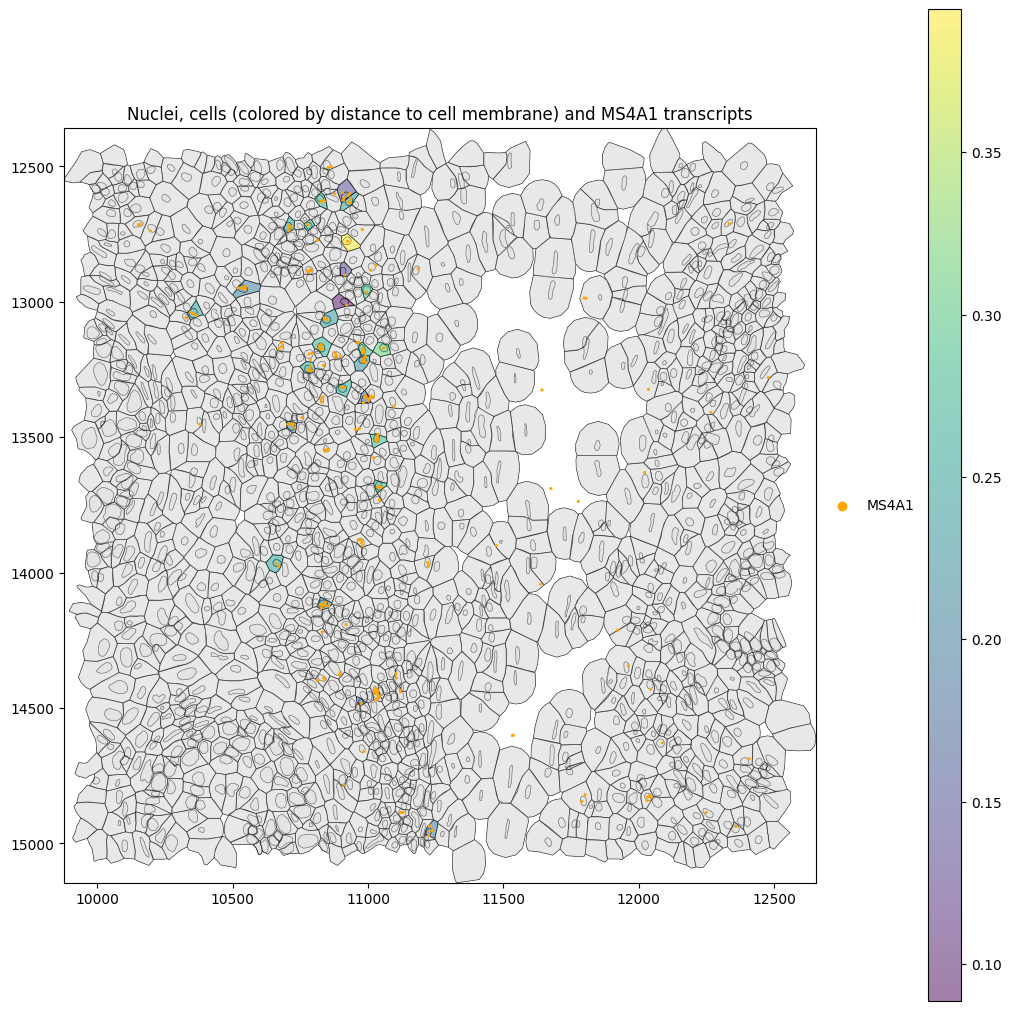

In [65]:
st_xenium.sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="distance_to_cell_membrane_norm_MS4A1",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=["MS4A1"],
    palette=["orange"],
).pl.show(figsize=(10,10), title="Nuclei, cells (colored by distance to cell membrane) and MS4A1 transcripts", colorbar=True)

Let's compute the mean distance to the nucleus and cell membrane to verify this.

In [66]:
for _method, st in st_dict.items():
    st.ps.distance_to_membrane(genes = "MS4A1", 
                                   cell_type_query="B", 
                                   membrane_region="nucleus",
                                   restrict_to_within_boundary=True)

In [68]:
xenium_cell_membrane = st_xenium.sdata.tables["table"].obs["distance_to_cell_membrane_norm_MS4A1"].mean()
xenium_nucleus_membrane = st_xenium.sdata.tables["table"].obs["distance_to_nucleus_membrane_norm_MS4A1"].mean()

print("Xenium:")
print(f"Mean distance of MS4A1 transcripts to cell membrane: {xenium_cell_membrane}.")
print(f"Mean distance of MS4A1 transcripts to nucleus membrane: {xenium_nucleus_membrane}.")

Xenium:
Mean distance of MS4A1 transcripts to cell membrane: 0.2337680414403614.
Mean distance of MS4A1 transcripts to nucleus membrane: 0.10078348677121293.


In [70]:
proseg_cell_membrane = st_proseg2.sdata.tables["table"].obs["distance_to_cell_membrane_norm_MS4A1"].mean()
proseg_nucleus_membrane = st_proseg2.sdata.tables["table"].obs["distance_to_nucleus_membrane_norm_MS4A1"].mean()

print("Xenium:")
print(f"Mean distance of MS4A1 transcripts to cell membrane: {proseg_cell_membrane}.")
print(f"Mean distance of MS4A1 transcripts to nucleus membrane: {proseg_nucleus_membrane}.")

Xenium:
Mean distance of MS4A1 transcripts to cell membrane: 0.07180125104927072.
Mean distance of MS4A1 transcripts to nucleus membrane: 0.044817586706642924.


## Percentage of points in compartments

In [10]:
st.ps.percentage_points_compartments()

,n_total,n_in_cell,n_outside_cell,n_in_nucleus_overlap,n_in_cytoplasm,pct_outside_cell,pct_nucleus,pct_cytoplasm
assignment,,,,,,,,
70026.0,1,0,0,0,0,0.000000,0.000000,0.000000
70066.0,16,11,5,6,5,31.250000,37.500000,31.250000
70067.0,5,3,2,0,3,40.000000,0.000000,60.000000
70068.0,3,0,0,0,0,0.000000,0.000000,0.000000
70069.0,31,20,11,11,9,35.483871,35.483871,29.032258
...,...,...,...,...,...,...,...,...
76434.0,87,74,13,58,16,14.942529,66.666667,18.390805
76435.0,110,91,19,66,25,17.272727,60.000000,22.727273
76436.0,39,33,6,26,7,15.384615,66.666667,17.948718


In [11]:
sdata["table"].obs

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,region,cell_area,best_nuc_id,IoU,nucleus_fraction,distance_norm_all_genes,distance_to_membrane_norm_ERBB2,pct_outside_cell,pct_nucleus,pct_cytoplasm
70066,70066,78094,2137.753418,2658.982178,0.250000,4,10.00,116.0,1.0,cell_boundaries,29.0,78094.0,0.372469,0.909792,0.063411,NaN,31.250000,37.500000,31.250000
70067,70067,78080,2121.160645,2665.461914,0.372500,5,50.00,288.0,1.0,cell_boundaries,81.0,NaN,NaN,NaN,NaN,NaN,40.000000,0.000000,60.000000
70069,70069,78081,2123.983643,2673.481445,0.338043,7,28.75,214.0,1.0,cell_boundaries,43.0,78081.0,0.621191,0.938538,0.284646,NaN,35.483871,35.483871,29.032258
70070,70070,78084,2129.758057,2670.460205,0.421512,3,32.25,216.0,1.0,cell_boundaries,69.0,78084.0,0.357129,0.969828,0.026450,NaN,15.116279,36.046512,48.837209
70071,70071,78083,2125.497559,2679.595215,0.426923,7,32.50,248.0,1.0,cell_boundaries,40.0,78083.0,0.662761,0.994992,0.092369,NaN,35.294118,55.882353,8.823529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76434,76434,94082,2635.241211,3170.337646,0.458893,7,37.25,266.0,1.0,cell_boundaries,50.0,94082.0,0.601019,0.991662,0.009633,NaN,14.942529,66.666667,18.390805
76435,76435,94078,2654.622314,3156.071777,0.441912,3,85.00,400.0,1.0,cell_boundaries,159.0,94078.0,0.275061,0.914519,0.095396,NaN,17.272727,60.000000,22.727273
76436,76436,94094,2628.212891,3188.504639,0.377793,7,44.75,284.0,1.0,cell_boundaries,80.0,94094.0,0.356451,1.000000,0.115107,NaN,15.384615,66.666667,17.948718
76439,76439,94091,2643.693848,3185.354980,0.370924,7,46.00,292.0,1.0,cell_boundaries,85.0,94091.0,0.306790,1.000000,0.025573,NaN,6.451613,65.591398,27.956989


In [12]:
sdata["nucleus_boundaries"]

,geometry
cell_id,
6327,"POLYGON ((2473.288 2681.75, 2472.225 2682.6, 2..."
6328,"POLYGON ((2470.312 2698.538, 2468.4 2698.962, ..."
6330,"POLYGON ((2482 2746.137, 2480.725 2747.837, 24..."
6331,"POLYGON ((2494.75 3081.675, 2493.9 3082.312, 2..."
6332,"POLYGON ((2486.25 2694.288, 2484.762 2695.988,..."
...,...
95953,"POLYGON ((2594.625 2674.312, 2593.137 2675.375..."
95954,"POLYGON ((2593.137 2653.913, 2591.863 2654.337..."
95955,"POLYGON ((2592.288 2669, 2591.65 2669.85, 2590..."


In [13]:
import pandas as pd

In [14]:
def plot_cell_with_nucleus_and_transcripts(
    cid: float | int, title: str, pix_to_um_scale_factor: float = 0.2125, repositioned_transcripts: bool = False
):
    # add annotation of this cell to .obs
    sdata["table"].obs["focal_cell"] = sdata["table"].obs["cell_id"] == cid

    # compute x,y of cell and nucleus centroids in µm space
    centroid_x_cell = sdata["cell_boundaries"].loc[cid].geometry.centroid.x / pix_to_um_scale_factor
    centroid_y_cell = sdata["cell_boundaries"].loc[cid].geometry.centroid.y / pix_to_um_scale_factor

    nid = sdata["table"].obs.loc[sdata["table"].obs["cell_id"] == cid, "best_nuc_id"].dropna().astype(int)
    centroid_x_nucleus = sdata["nucleus_boundaries"].loc[nid].geometry.centroid.x / pix_to_um_scale_factor
    centroid_y_nucleus = sdata["nucleus_boundaries"].loc[nid].geometry.centroid.y / pix_to_um_scale_factor

    # add annotation of this cell to .points and build new `PointsModel``
    trans = sdata.points["transcripts"].compute()
    trans["focal_cell"] = "other_cells"
    trans.loc[trans["cell_id"] == cid, "focal_cell"] = "focal_cell"
    trans["focal_cell"] = trans["focal_cell"].astype("category")
    if repositioned_transcripts:
        trans = trans.drop(columns=["x", "y", "z"])
        trans = trans.rename(columns={"repositioned_x": "x", "repositioned_y": "y", "repositioned_z": "z"})
    sdata.points["transcripts_2"] = sd.models.PointsModel.parse(trans)
    T = sd.transformations.get_transformation(sdata.points["transcripts"])
    sd.transformations.set_transformation(sdata.points["transcripts_2"], T)

    # plot cell and transcripts of that cell
    axes = plt.subplots(1, 1, figsize=(16, 16), constrained_layout=True)[1]

    sdata.pl.render_shapes(
        element="nucleus_boundaries",
        fill_alpha=0.2,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.render_shapes(
        element="cell_boundaries",
        color="focal_cell",
        fill_alpha=0.1,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="blue",
    ).pl.render_points(
        "transcripts_2",
        color="focal_cell",
        fill_alpha=0.1,
        groups=["focal_cell"],
        palette=["red"],
    ).pl.show(
        ax=axes,
        title=title,
        colorbar=True,
        figsize=(10, 10),
    )

    # landmark for cell and nucleus centroid
    axes.scatter([centroid_x_cell], [centroid_y_cell], marker="+", s=400, c="black", linewidths=2, zorder=10, alpha=0.4)
    axes.scatter([centroid_x_nucleus], [centroid_y_nucleus], marker="+", s=400, c="black", linewidths=2, zorder=10)

In [ ]:
plot_cell_with_nucleus_and_transcripts(cid="aphgkeah-1", pix_to_um_scale_factor=1, title="")

We can also plot this metric in space.

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/render.py:821: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _c

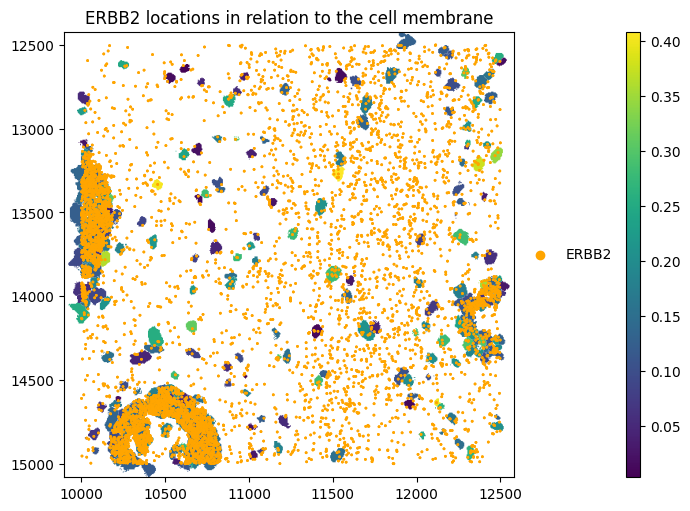

In [ ]:
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["distance_to_membrane_norm_ERBB2"].notna()]

sdata_plot.pl.render_shapes(
    "cell_boundaries",
    color="distance_to_membrane_norm_ERBB2",
).pl.render_points(
    "transcripts",
    color="gene",
    groups="ERBB2",
    palette="orange",
).pl.show(
    title="ERBB2 locations in relation to the cell membrane",
    coordinate_systems="global",
    figsize=(10, 5),
)

We note that the two metrics are complementary to each other. However, there are situations with irregularly shaped cells where the distance to the centroid might be very small although the transcripts are clearly on the boarder of the cell.

## Membrane distance skewness

In [10]:
st.ps.membrane_distance_skewness(["PTPRC"],
                                 min_transcripts=5)

,assignment,skew_dist_to_membrane_PTPRC
0,70137.0,NaN
1,73942.0,NaN
2,73946.0,NaN
3,70582.0,NaN
4,70573.0,0.028833
...,...,...
679,72307.0,NaN
680,70865.0,NaN
681,70966.0,NaN
682,70961.0,NaN


In [31]:
sdata["table"].obs

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method,label_id,region,skew_dist_to_membrane_ERBB2
3774,aphcnklp-1,830.097471,1152.572969,66,0,0,0,0,13,79,52.652189,25.874532,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3775,cell_boundaries,NaN
3790,aphdnoam-1,903.576230,1148.448945,101,0,0,0,0,16,117,29.035470,NaN,0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3791,cell_boundaries,NaN
3791,aphdpfhl-1,913.759580,1148.394258,298,0,0,0,0,59,357,94.150785,66.424846,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3792,cell_boundaries,NaN
3793,aphebebn-1,926.788389,1150.407930,464,0,0,0,0,96,560,184.463288,102.188597,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3794,cell_boundaries,NaN
3801,aphejokb-1,976.144590,1181.338594,225,0,0,0,0,34,259,89.499691,44.930470,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3802,cell_boundaries,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18253,oemhhakm-1,900.100156,1224.799531,6,0,0,0,0,0,6,15.985313,15.985313,1,Segmented by nucleus expansion of 5.0µm,18254,cell_boundaries,NaN
18254,oemhhohn-1,803.936582,1239.208711,0,0,0,0,0,0,0,5.057500,5.057500,1,Segmented by nucleus expansion of 5.0µm,18255,cell_boundaries,NaN
18255,oemhjdii-1,811.537168,1277.467500,6,0,0,0,0,4,10,27.093751,27.093751,1,Segmented by nucleus expansion of 5.0µm,18256,cell_boundaries,NaN
18256,oemhkbjo-1,840.029844,1309.799531,11,0,0,0,0,2,13,11.063282,11.063282,1,Segmented by nucleus expansion of 5.0µm,18257,cell_boundaries,NaN


<Axes: xlabel='distance_to_membrane_norm_all_genes', ylabel='skew_dist_to_membrane_all_genes'>

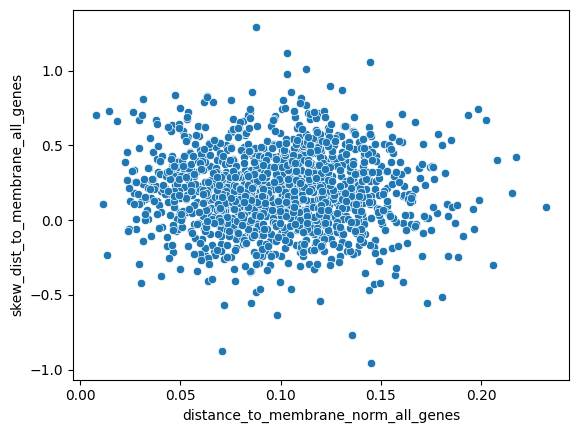

In [24]:
import seaborn as sns
sns.scatterplot(data=sdata["table"].obs, x="distance_to_membrane_norm_all_genes", y="skew_dist_to_membrane_all_genes")

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/render.py:821: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _c

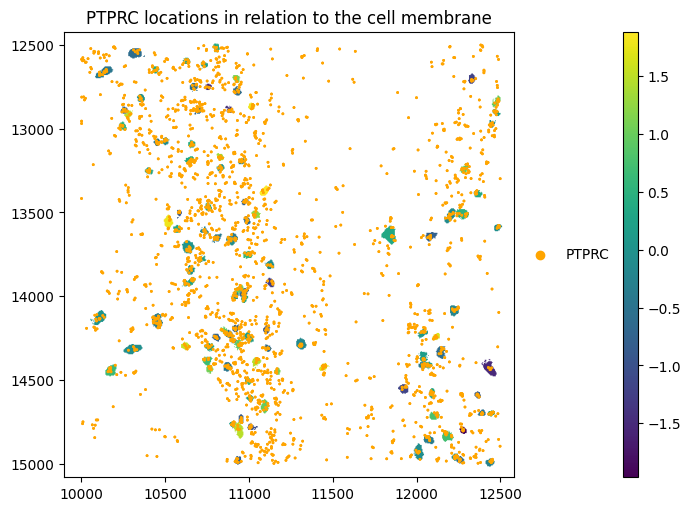

In [11]:
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["skew_dist_to_membrane_PTPRC"].notna()]

sdata_plot.pl.render_shapes(
    "cell_boundaries",
    color="skew_dist_to_membrane_PTPRC",
).pl.render_points(
    "transcripts",
    color="gene",
    groups="PTPRC",
    palette="orange",
).pl.show(
    title="PTPRC locations in relation to the cell membrane",
    coordinate_systems="global",
    figsize=(10, 5),
)

WARNING  Found 1141 NaN values in color data. These observations will be colored with the 'na_color'.              
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
WARNING  Found 1355 NaN values in color data. These observations will be colored with the 'na_color'.              
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


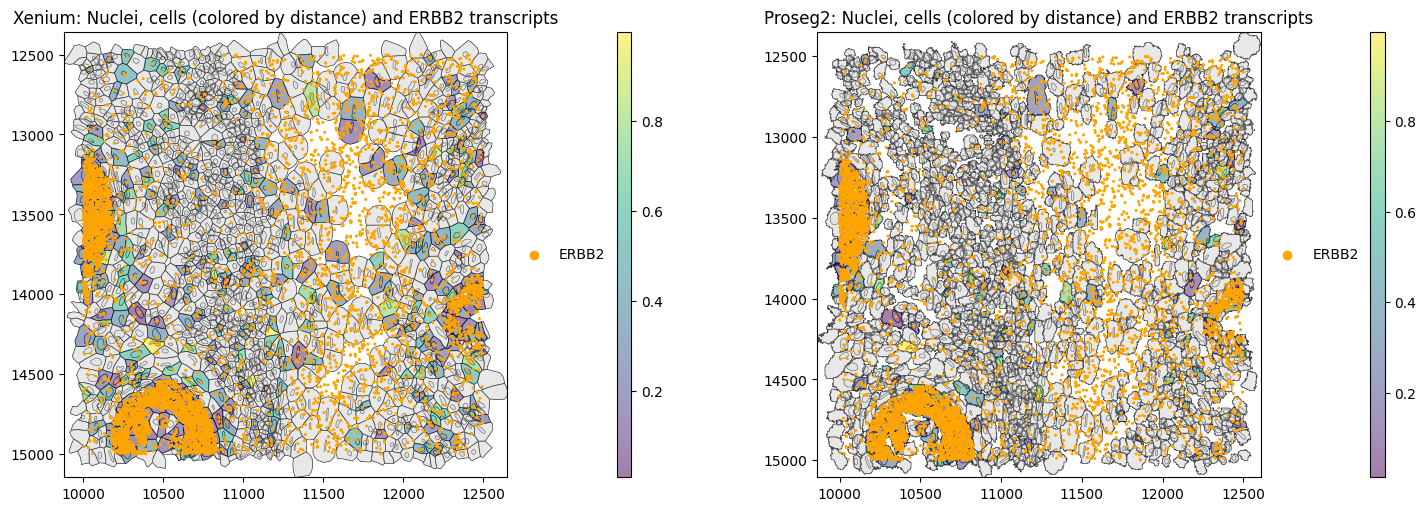

In [17]:
axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)[1].flatten()

st_xenium.sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="distance_norm_ERBB2",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=["ERBB2"],
    palette=["orange"],
).pl.show(ax=axes[0], title="Xenium: Nuclei, cells (colored by distance) and ERBB2 transcripts", colorbar=True)

st_proseg2.sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="distance_norm_ERBB2",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_points(
    "transcripts",
    color="gene",
    groups=["ERBB2"],
    palette=["orange"],
).pl.show(ax=axes[1], title="Proseg2: Nuclei, cells (colored by distance) and ERBB2 transcripts", colorbar=True)